# Build LogD GAT model.

This notebook shows how to build an attention-based model (GATv2Conv) to train, predict and evaluate LogD from Chembl data. 

In [1]:
import pandas as pd
import torch
import torch.nn.functional as F
import torch.nn as nn
import numpy as np

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors3D, rdMolDescriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import NNConv, global_mean_pool

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import matplotlib.pyplot as plt
import seaborn as sns

import pathlib
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Setup.

In [2]:
readout = 'LogD7.4'

In [3]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{readout}"
DATA.mkdir(parents=True, exist_ok=True)

In [4]:
# Load chembl data

df = pd.read_csv(f'{DATA}/{readout}_chembl.csv',index_col=None)
len(df)

7713

In [5]:
smiles_list = df['smiles'].tolist()
logd_values = df['standard_value'].tolist()

Pytorch geometric fix

In [6]:
# Here we define our own data structure for Pytorch Geometric to use in the model.
# Why? In the functions below, PyG's Batch.from_data_list tries to automatically 
# concatenate all descriptors and layers and gets the feature vector size wrong unless instructed not to. 
# (1D vector of 288 instead of 2D vector odf 32 x 9 chemical features)  
# global_features should be stacked (batched), not concatenated - the __cat_dim__ method controls that.

from torch_geometric.data import Data

class MoleculeData(Data):
    def __inc__(self, key, value, *args, **kwargs):
        return super().__inc__(key, value)

    def __cat_dim__(self, key, value, *args, **kwargs):
        if key == 'global_features':
            return None  # do not concatenate along any dimension
        return super().__cat_dim__(key, value)


## Featurisation step.

### Add Morgan fps and 3D descriptors as global predictors

In [7]:
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

def get_morgan_fingerprint(mol, radius=2, nBits=1024):
    generator = GetMorganGenerator(radius=radius, fpSize=nBits)
    fp = generator.GetFingerprint(mol)
    arr = np.zeros((nBits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr.astype(np.float32)


In [8]:
def get_3d_descriptors(mol):
    mol = Chem.AddHs(mol)

    try:
        if AllChem.EmbedMolecule(mol, AllChem.ETKDG()) != 0:
            return np.zeros(6, dtype=np.float32)

        # Check for UFF optimization support
        try:
            AllChem.UFFOptimizeMolecule(mol)
        except:
            return np.zeros(6, dtype=np.float32)

        descs = [
            Descriptors3D.Asphericity(mol),
            Descriptors3D.Eccentricity(mol),
            Descriptors3D.InertialShapeFactor(mol),
            Descriptors3D.SpherocityIndex(mol),
            rdMolDescriptors.CalcVolume(mol),
            rdMolDescriptors.CalcLabuteASA(mol)
        ]

        descs = [0.0 if np.isnan(d) or np.isinf(d) else d for d in descs]
        return np.array(descs, dtype=np.float32)

    except Exception as e:
        return np.zeros(6, dtype=np.float32)

In [ ]:
# We can get reasonable results (R^2 ~ 0.5) with simple atomic features.
# But as we are trying to predict a more complex phenomena, we can benefit from RdKit 
# descriptors to encode hybridisation, partial charges, etc.
# LogD prediction should improve from here.

from rdkit.Chem import rdPartialCharges, rdMolDescriptors, Descriptors, PeriodicTable

descriptor_functions = [
    Descriptors.MolWt,
    Descriptors.MolLogP,
    Descriptors.NumHDonors,
    Descriptors.NumHAcceptors,
    Descriptors.TPSA,
    Descriptors.FractionCSP3,
    Descriptors.HeavyAtomCount,
    Descriptors.NumRotatableBonds,
    Descriptors.RingCount,
    Descriptors.MolMR,             # ADDITIONAL DESCRIPTORS: # Molar Refractivity
    Descriptors.BertzCT,           # Topological complexity
    Descriptors.NumValenceElectrons,
    Descriptors.NumAliphaticRings,
    Descriptors.NumAromaticRings,
    Descriptors.HeavyAtomMolWt,
    Descriptors.ExactMolWt,
    Descriptors.MaxPartialCharge,
    Descriptors.MinPartialCharge,
    Descriptors.MaxAbsPartialCharge,
    Descriptors.MinAbsPartialCharge
]

# Precompute a dict of electronegativities (Pauling scale)
electronegativity_dict = {
    1: 2.20, 6: 2.55, 7: 3.04, 8: 3.44, 9: 3.98, 15: 2.19,
    16: 2.58, 17: 3.16, 35: 2.96, 53: 2.66,
}

# List of metals by atomic number (common metals)
metals = {
    3, 4, 11, 12, 13, 19, 20, 21, 22, 23, 24, 25,
    26, 27, 28, 29, 30, 37, 38, 39, 40, 41, 42,
    43, 44, 45, 46, 47, 48, 49, 55, 56, 57, 72,
    73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83,
    87, 88, 89, 104, 105, 106, 107, 108, 109, 110,
    111, 112, 113, 114, 115, 116
}

def one_hot_encoding(x, allowable_set):
    if x not in allowable_set:
        x = allowable_set[-1]  # fallback to "unknown"
    return [int(x == s) for s in allowable_set]

def get_atom_features(atom, mol=None):
    pt = Chem.GetPeriodicTable()
    features = []

    # Atom symbol (one-hot + unknown)
    features += one_hot_encoding(atom.GetSymbol(),
                                ['C', 'N', 'O', 'F', 'P', 'S', 'Cl', 'Br', 'I', 'H',
                                 'B', 'Si', 'Se', 'As', 'Al', 'Zn', 'Cu', 'Ni', 'Fe', 'other'])

    # Hybridization (one-hot)
    features += one_hot_encoding(atom.GetHybridization(),
                                [Chem.rdchem.HybridizationType.SP,
                                 Chem.rdchem.HybridizationType.SP2,
                                 Chem.rdchem.HybridizationType.SP3,
                                 Chem.rdchem.HybridizationType.SP3D,
                                 Chem.rdchem.HybridizationType.SP3D2,
                                 Chem.rdchem.HybridizationType.UNSPECIFIED])

    # Integer-valued features (can be scaled later if needed)
    features += [
        atom.GetDegree(),               # n_bonded neighbors
        atom.GetFormalCharge(),
        atom.GetNumRadicalElectrons(),
        int(atom.GetIsAromatic())
    ]

    atomic_num = atom.GetAtomicNum()

    # Physical properties from periodic table (normalised to 0-1)
    # We could prpbably play with this, if we want to.
    features += [
        pt.GetAtomicWeight(atomic_num) / 200,                 # ~1–200 → 0–1
        pt.GetRvdw(atomic_num) / 2.5,                         # ~0.5–2.5 → 0–1
        electronegativity_dict.get(atomic_num, 0.0) / 4.0,    # ~0–4 → 0–1
        pt.GetNOuterElecs(atomic_num) / 8.0,                  # Valence electrons, ~0–8
        1.0 if atomic_num in metals else 0.0                  # binary
    ]


    # Partial charge (Gasteiger)
    # Something else we could play with (e.g. AM1-BCC) but this adds cost.
    if mol is not None:
        try:
            charge = float(atom.GetProp('_GasteigerCharge'))
            if np.isnan(charge) or np.isinf(charge):
                charge = 0.0
        except:
            charge = 0.0
        features += [charge]
    else:
        features += [0.0]

    return np.array(features, dtype=np.float32)

def get_bond_features(bond):
    bond_type = bond.GetBondType()
    features = [
        int(bond_type == Chem.rdchem.BondType.SINGLE),
        int(bond_type == Chem.rdchem.BondType.DOUBLE),
        int(bond_type == Chem.rdchem.BondType.TRIPLE),
        int(bond_type == Chem.rdchem.BondType.AROMATIC),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing()),
    ]
    return np.array(features, dtype=np.float32)


## Convert Featurised molecules into graph for the model.

In [10]:
# def mol_to_graph(smiles: str, label: float = None):
#     mol = Chem.MolFromSmiles(smiles)
#     if mol is None:
#         return None

#     try:
#         rdPartialCharges.ComputeGasteigerCharges(mol)
#     except:
#         pass

#     atom_features = [get_atom_features(atom, mol) for atom in mol.GetAtoms()]
#     x = torch.tensor(atom_features, dtype=torch.float)

#     edge_index = []
#     edge_attr = []
#     for bond in mol.GetBonds():
#         i = bond.GetBeginAtomIdx()
#         j = bond.GetEndAtomIdx()
#         bond_feat = get_bond_features(bond)
#         edge_index += [[i, j], [j, i]]
#         edge_attr += [bond_feat, bond_feat]

#     edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
#     edge_attr = torch.tensor(edge_attr, dtype=torch.float)

#     global_features = []
#     for func in descriptor_functions:
#         try:
#             val = func(mol)
#             if np.isnan(val) or np.isinf(val):
#                 val = 0.0
#         except:
#             val = 0.0
#         global_features.append(val)
#     global_features = torch.tensor(global_features, dtype=torch.float32)

#     # Use MoleculeData class we added here instead of Data
#     data = MoleculeData(x=x, edge_index=edge_index, edge_attr=edge_attr, global_features=global_features)

#     if label is not None:
#         data.y = torch.tensor([label], dtype=torch.float)

#     return data

def mol_to_graph(smiles: str, label: float = None, radius=2, nBits=1024):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    try:
        rdPartialCharges.ComputeGasteigerCharges(mol)
    except:
        pass

    atom_features = [get_atom_features(atom, mol) for atom in mol.GetAtoms()]
    x = torch.tensor(atom_features, dtype=torch.float)

    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bond_feat = get_bond_features(bond)
        edge_index += [[i, j], [j, i]]
        edge_attr += [bond_feat, bond_feat]

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # Global features
    global_features = []

    # RDKit descriptors
    for func in descriptor_functions:
        try:
            val = func(mol)
            if np.isnan(val) or np.isinf(val):
                val = 0.0
        except:
            val = 0.0
        global_features.append(val)

    # Add Morgan fingerprint
    fp = get_morgan_fingerprint(mol, radius=radius, nBits=nBits)
    global_features += fp.tolist()

    # Add 3D descriptors
    desc3d = get_3d_descriptors(mol)
    global_features += desc3d.tolist()

    global_features = torch.tensor(global_features, dtype=torch.float32)

    data = MoleculeData(x=x, edge_index=edge_index, edge_attr=edge_attr, global_features=global_features)

    if label is not None:
        data.y = torch.tensor([label], dtype=torch.float)

    return data


Data loader code.

In [11]:
# We have to tell the DataLoader which features to expect.

def compute_global_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        # fallback vector of zeros if mol fails
        return torch.zeros(len(descriptor_functions), dtype=torch.float)
    feats = [fn(mol) for fn in descriptor_functions]
    return torch.tensor(feats, dtype=torch.float)

In [12]:
from torch_geometric.data import Batch

def _collate(batch_list):
    return Batch.from_data_list(batch_list)

We should get better results if we do splits by Murcko scaffold, rather than random where some SMILES will appear in multiple splits.

In [13]:
import os
from multiprocessing import Pool
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict
import random

# -------------------------------
# Step 1: Define scaffold split
# -------------------------------

def generate_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return ""
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

def scaffold_split(smiles_list, logd_values, val_ratio=0.2, seed=42):
    scaffold_dict = defaultdict(list)
    for smi, lbl in zip(smiles_list, logd_values):
        scaffold = generate_scaffold(smi)
        scaffold_dict[scaffold].append((smi, lbl))

    scaffold_sets = list(scaffold_dict.items())
    random.seed(seed)
    random.shuffle(scaffold_sets)

    train_data, val_data = [], []
    total_size = len(smiles_list)
    val_size = int(total_size * val_ratio)
    current_val_size = 0

    for scaffold, examples in scaffold_sets:
        if current_val_size + len(examples) <= val_size:
            val_data.extend(examples)
            current_val_size += len(examples)
        else:
            train_data.extend(examples)

    train_smi, train_lbl = zip(*train_data)
    val_smi, val_lbl     = zip(*val_data)
    return list(train_smi), list(train_lbl), list(val_smi), list(val_lbl)

# -------------------------------
# Step 2: Apply scaffold split
# -------------------------------

train_smi, train_lbl, val_smi, val_lbl = scaffold_split(smiles_list, logd_values, val_ratio=0.2)

In [14]:
# import os
# from multiprocessing import Pool

# # function to adjust number of cpus for calculation below, leaving some free for other work

# total_cpus = os.cpu_count()
# reserve_cpus = 4  # make sure we leave this many CPUs free
# num_workers = max(1, total_cpus - reserve_cpus)

# print(f"Using {num_workers} out of {total_cpus} available CPU cores.")

# def process_mol(args):
#     smi, lbl = args
#     data = mol_to_graph(smi, lbl)
#     return data

# with Pool(processes=num_workers) as pool:
#     results = pool.map(process_mol, zip(smiles_list, logd_values))

# data_list = [data for data in results if data is not None]

# from torch_geometric.loader import DataLoader

# loader = DataLoader(data_list, batch_size=16, shuffle=True, collate_fn=_collate)

# -------------------------------
# Step 3: Multiprocessing for graph construction
# -------------------------------

def process_mol(args):
    smi, lbl = args
    return mol_to_graph(smi, lbl)

# Detect and assign CPU cores
total_cpus = os.cpu_count()
reserve_cpus = 4
num_workers = max(1, total_cpus - reserve_cpus)
print(f"Using {num_workers} out of {total_cpus} available CPU cores.")

with Pool(processes=num_workers) as pool:
    train_results = pool.map(process_mol, zip(train_smi, train_lbl))
    val_results   = pool.map(process_mol, zip(val_smi, val_lbl))

train_list = [d for d in train_results if d is not None]
val_list   = [d for d in val_results if d is not None]

# -------------------------------
# Step 4: Loaders
# -------------------------------

from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_list, batch_size=32, shuffle=True, collate_fn=_collate)
val_loader   = DataLoader(val_list, batch_size=32, shuffle=False, collate_fn=_collate)

Using 16 out of 20 available CPU cores.


/tmp/ipykernel_9798/161395823.py:56: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x = torch.tensor(atom_features, dtype=torch.float)
/tmp/ipykernel_9798/161395823.py:56: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x = torch.tensor(atom_features, dtype=torch.float)
/tmp/ipykernel_9798/161395823.py:56: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.c

## The Regression model definition.

In [15]:
# Use GATv2Conv as the attention should more effectively capture functional groups.

from torch_geometric.nn import GATv2Conv, global_mean_pool

# class GATv2Regressor(torch.nn.Module):
#     def __init__(self, input_dim, edge_dim, hidden_dim=128, heads=2, global_feat_dim=0):
#         super().__init__()

#         self.edge_encoder = torch.nn.Linear(edge_dim, hidden_dim)

#         self.gat1 = GATv2Conv(input_dim, hidden_dim, heads=heads, dropout=0.1, edge_dim=hidden_dim)
#         self.gat2 = GATv2Conv(hidden_dim * heads, hidden_dim, heads=1, concat=True, dropout=0.1, edge_dim=hidden_dim)

#         # Adjust input dimension of first linear layer to include global descriptor size
#         self.lin = torch.nn.Sequential(
#             torch.nn.Linear(hidden_dim + global_feat_dim, hidden_dim // 2),
#             torch.nn.ReLU(),
#             torch.nn.Linear(hidden_dim // 2, 1)
#         )

#     def forward(self, data):
#         x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch

#         device = next(self.parameters()).device
#         x, edge_index, edge_attr, batch = x.to(device), edge_index.to(device), edge_attr.to(device), batch.to(device)

#         edge_attr = self.edge_encoder(edge_attr)

#         x = self.gat1(x, edge_index, edge_attr)
#         x = F.elu(x)
#         x = self.gat2(x, edge_index, edge_attr)
#         x = F.elu(x)

#         x = global_mean_pool(x, batch)  # [batch_size, hidden_dim]

#         if hasattr(data, 'global_features'):
#             global_features = data.global_features.to(x.device)  # [batch_size, global_feat_dim]
#             #print(f"Shape x: {x.shape}, global_features: {global_features.shape}") # Debugging line - commented out unless necessary
#             x = torch.cat([x, global_features], dim=1)

#         return self.lin(x).squeeze(1)

class GATv2Regressor(nn.Module):
    def __init__(self, input_dim, edge_dim, hidden_dim=128, heads=2, global_feat_dim=0):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.use_global = global_feat_dim > 0

        # Edge encoder (optional MLP version)
        self.edge_encoder = nn.Sequential(
            nn.Linear(edge_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        # GNN layers
        self.gat1 = GATv2Conv(input_dim, hidden_dim, heads=heads, dropout=0.1, edge_dim=hidden_dim)
        self.gat2 = GATv2Conv(hidden_dim * heads, hidden_dim, heads=1, concat=True, dropout=0.1, edge_dim=hidden_dim)

        # MLP for global features
        if self.use_global:
            self.global_mlp = nn.Sequential(
                nn.Linear(global_feat_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU()
            )
            final_input_dim = hidden_dim + (hidden_dim // 2)
        else:
            final_input_dim = hidden_dim

        # Final regressor head
        self.lin = nn.Sequential(
            nn.Linear(final_input_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        device = x.device

        edge_attr = self.edge_encoder(edge_attr)

        x = self.gat1(x, edge_index, edge_attr)
        x = F.elu(x)
        x = self.gat2(x, edge_index, edge_attr)
        x = F.elu(x)

        x = global_mean_pool(x, batch)

        if self.use_global and hasattr(data, 'global_features'):
            g_feat = self.global_mlp(data.global_features.to(x.device))
            x = torch.cat([x, g_feat], dim=1)

        return self.lin(x).squeeze(1)

## Training loop.

With train / val split, early stopping and grid search.

In [16]:
# from sklearn.model_selection import train_test_split

# train_list, val_list = train_test_split(data_list, test_size=0.2, random_state=42)

train_loader = DataLoader(train_list, batch_size=32, shuffle=True, collate_fn=_collate)
val_loader = DataLoader(val_list, batch_size=32, shuffle=False, collate_fn=_collate)


In [17]:
def train_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = loss_fn(out, batch.y.to(device).float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            loss = loss_fn(out, batch.y.to(device).float())
            total_loss += loss.item()
            all_preds.append(out.cpu())
            all_labels.append(batch.y.cpu())
    return total_loss / len(loader), torch.cat(all_preds), torch.cat(all_labels)

In [18]:
def train_with_early_stopping(params, train_list, val_list):
    # Create loaders using the batch size from param grid
    train_loader = DataLoader(train_list, batch_size=params['batch_size'], shuffle=True, collate_fn=_collate)
    val_loader   = DataLoader(val_list, batch_size=params['batch_size'], shuffle=False, collate_fn=_collate)

    model = GATv2Regressor(
        input_dim=params['input_dim'],
        edge_dim=params['edge_dim'],
        hidden_dim=params['hidden_dim'],
        heads=2,
        global_feat_dim=params.get('global_feat_dim', 0)
    )
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    loss_fn = torch.nn.MSELoss()

    best_val_loss = float('inf')
    patience = 10
    patience_counter = 0

    for epoch in range(100):
        train_loss = train_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss, _, _ = eval_epoch(model, val_loader, loss_fn, device)
        print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if not torch.isnan(torch.tensor(val_loss)) and val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered")
            break

    model.load_state_dict(torch.load('best_model.pth'))
    return model, best_val_loss


With hyperparameter tuning.

In [19]:
import itertools

# Get dimensions from a real training sample
sample = train_list[0]
input_dim = sample.x.shape[1]
edge_dim = sample.edge_attr.shape[1]
global_feat_dim = sample.global_features.shape[0]


# param_grid = {
#     'lr': [0.001],
#     'hidden_dim': [64, 128],
# }

# Larger grid search helps

param_grid = {
    'lr': [1e-4, 5e-4, 1e-3],
    'hidden_dim': [64, 128, 256],
    'dropout': [0.0, 0.1, 0.2],
    'batch_size': [16, 32, 64]
}

best_model = None
best_val_loss = float('inf')
best_params = None

for lr, hidden_dim, dropout, batch_size in itertools.product(
        param_grid['lr'], param_grid['hidden_dim'], param_grid['dropout'], param_grid['batch_size']):
    
    print(f"Training with lr={lr}, hidden_dim={hidden_dim}, dropout={dropout}, batch_size={batch_size}")
        
    params = {
        'lr': lr,
        'hidden_dim': hidden_dim,
        'dropout': dropout,
        'batch_size': batch_size,
        'input_dim': input_dim,
        'edge_dim': edge_dim,
        'global_feat_dim': global_feat_dim
    }

    model, val_loss = train_with_early_stopping(params, train_list, val_list)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model
        best_params = params

print(f"\nBest params: {best_params}")


Training with lr=0.0001, hidden_dim=64, dropout=0.0, batch_size=16
Epoch 1 | Train Loss: 2.2932 | Val Loss: 1.6525
Epoch 2 | Train Loss: 1.7333 | Val Loss: 1.5478
Epoch 3 | Train Loss: 1.5831 | Val Loss: 1.3502
Epoch 4 | Train Loss: 1.4071 | Val Loss: 1.2598
Epoch 5 | Train Loss: 1.3062 | Val Loss: 1.2131
Epoch 6 | Train Loss: 1.2159 | Val Loss: 1.1377
Epoch 7 | Train Loss: 1.1213 | Val Loss: 1.2123
Epoch 8 | Train Loss: 1.0334 | Val Loss: 1.0720
Epoch 9 | Train Loss: 0.9805 | Val Loss: 1.1419
Epoch 10 | Train Loss: 0.9535 | Val Loss: 1.0212
Epoch 11 | Train Loss: 0.9037 | Val Loss: 0.9911
Epoch 12 | Train Loss: 0.8658 | Val Loss: 1.0534
Epoch 13 | Train Loss: 0.8590 | Val Loss: 0.9925
Epoch 14 | Train Loss: 0.8089 | Val Loss: 1.0485
Epoch 15 | Train Loss: 0.7999 | Val Loss: 0.9849
Epoch 16 | Train Loss: 0.7689 | Val Loss: 0.9579
Epoch 17 | Train Loss: 0.7697 | Val Loss: 0.9810
Epoch 18 | Train Loss: 0.7110 | Val Loss: 0.9830
Epoch 19 | Train Loss: 0.7365 | Val Loss: 1.0410
Epoch 20 | 

With the grid search, this model took ~ 90 mins to train.

## Evaluation


RMSE: 0.8771
MAE: 0.6451
R²: 0.6130


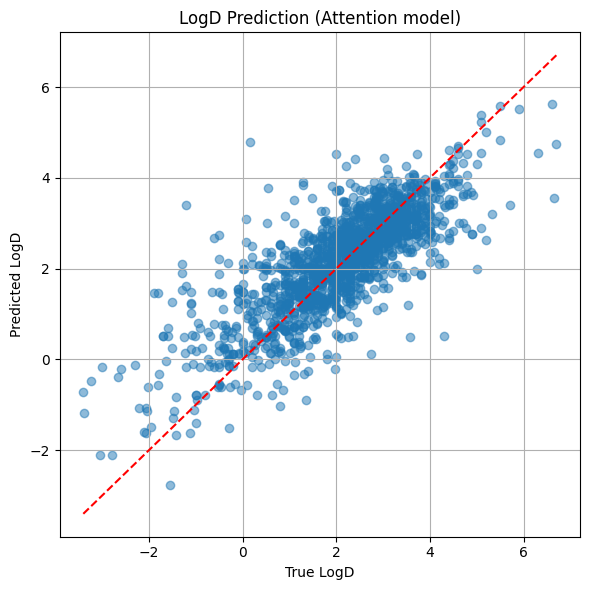

In [20]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        pred = model(batch)
        y_true.extend(batch.y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"\nRMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

# Plot true vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.xlabel("True LogD")
plt.ylabel("Predicted LogD")
plt.title("LogD Prediction (Attention model)")
plt.grid(True)
plt.tight_layout()
plt.savefig("logd_pred_vs_true.png", dpi=300)
plt.show()


* R^2 of ~0.61 is worse performing than the simpler model
* For now, we will keep the model and use it, although we could definitely work to improve it

In [21]:
torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": input_dim,
    "edge_dim": edge_dim,
    "hidden_dim": hidden_dim,
    "global_feat_dim": global_feat_dim
    }, "logd_gat_large.pt")